# INTRODUCTION

Hey there! Welcome to my notebook for the ISIC 2024 challenge—my first time tackling this competition. The goal is to build a model that can accurately detect skin lesions using the provided dataset. Throughout this notebook, I’ll walk you through my approach, which includes data preprocessing, augmentations, model building, and training using Keras and TensorFlow.

Here’s a quick overview of what I did:

1. Data Preprocessing: Cleaning and preparing the dataset for training.
2. Data Augmentation: Applying techniques to artificially expand the dataset and improve model generalization.
3. Model Building: Constructing a Convolutional Neural Network (CNN) using Keras and TensorFlow.
4. Training: Optimizing the model with appropriate loss functions and evaluation metrics.
5. Evaluation: Assessing the model’s performance using validation and test data.
I'm still learning, so if you have any suggestions or feedback, I’d love to hear them!

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras_cv
import keras
from keras import ops
import tensorflow as tf

import cv2
import pandas as pd
import numpy as np
from glob import glob
from tqdm.notebook import tqdm
import joblib

import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("KerasCV:", keras_cv.__version__)


TensorFlow: 2.16.1
Keras: 3.3.3
KerasCV: 0.9.0


In [ ]:
class CFG:
    verbose = 1  # Verbosity
    seed = 42  # Random seed
    neg_sample = 0.01 # Downsample negative calss
    pos_sample = 5.0  # Upsample positive class
    preset = "efficientnetv2_b2_imagenet"  # Name of pretrained classifier
    image_size = [128, 128]  # Input image size
    epochs = 200 # Training epochs
    batch_size = 256  # Batch size
    lr_mode = "cos" # LR scheduler mode from one of "cos", "step", "exp"
    class_names = ['target']
    num_classes = 1

In [ ]:
keras.utils.set_random_seed(CFG.seed)

In [ ]:
BASE_PATH = "/kaggle/input/isic-2024-challenge"


In [ ]:
# Train + Valid
df = pd.read_csv(f'{BASE_PATH}/train-metadata.csv', low_memory=False)
df = df.ffill()
display(df.head(2))

# Testing
testing_df = pd.read_csv(f'{BASE_PATH}/test-metadata.csv', low_memory=False)
testing_df = testing_df.ffill()
display(testing_df.head(2))

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455


,isic_id,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,tbp_lv_Aext,...,tbp_lv_radial_color_std_max,tbp_lv_stdL,tbp_lv_stdLExt,tbp_lv_symm_2axis,tbp_lv_symm_2axis_angle,tbp_lv_x,tbp_lv_y,tbp_lv_z,attribution,copyright_license
0,ISIC_0015657,IP_6074337,45.0,male,posterior torso,2.70,TBP tile: close-up,3D: XP,22.80433,20.007270,...,0.304827,1.281532,2.299935,0.479339,20,-155.06510,1511.222000,113.980100,Memorial Sloan Kettering Cancer Center,CC-BY
1,ISIC_0015729,IP_1664139,35.0,female,lower extremity,2.52,TBP tile: close-up,3D: XP,16.64867,9.657964,...,0.000000,1.271940,2.011223,0.426230,25,-112.36924,629.535889,-15.019287,"Frazer Institute, The University of Queensland...",CC-BY


In [ ]:
print("Class Distribution Before Sampling (%):")
display(df.target.value_counts(normalize=True)*100)

# Sampling
positive_df = df.query("target==0").sample(frac=CFG.neg_sample, random_state=CFG.seed)
negative_df = df.query("target==1").sample(frac=CFG.pos_sample, replace=True, random_state=CFG.seed)
df = pd.concat([positive_df, negative_df], axis=0).sample(frac=1.0)

print("\nCalss Distribution After Sampling (%):")
display(df.target.value_counts(normalize=True)*100)

Class Distribution Before Sampling (%):


target
0    99.902009
1     0.097991
Name: proportion, dtype: float64


Calss Distribution After Sampling (%):


target
0    67.09645
1    32.90355
Name: proportion, dtype: float64

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Assume df is your DataFrame and 'target' is the column with class labels
class_weights = compute_class_weight('balanced', classes=np.unique(df['target']), y=df['target'])
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: 0.7451959071624656, 1: 1.519592875318066}


In [ ]:
import h5py

training_validation_hdf5 = h5py.File(f"{BASE_PATH}/train-image.hdf5", 'r')
testing_hdf5 = h5py.File(f"{BASE_PATH}/test-image.hdf5", 'r')

Byte String: b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00'....
Image:


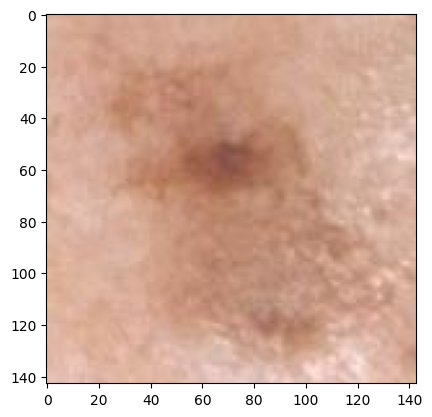

In [ ]:
isic_id = df.isic_id.iloc[0]

# Image as Byte String
byte_string = training_validation_hdf5[isic_id][()]
print(f"Byte String: {byte_string[:20]}....")

# Convert byte string to numpy array
nparr = np.frombuffer(byte_string, np.uint8)

print("Image:")
image = cv2.imdecode(nparr, cv2.IMREAD_COLOR)[...,::-1] # reverse last axis for bgr -> rgb
plt.imshow(image);

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

df = df.reset_index(drop=True) # ensure continuous index
df["fold"] = -1
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=CFG.seed)
for i, (training_idx, validation_idx) in enumerate(sgkf.split(df, y=df.target, groups=df.patient_id)):
    df.loc[validation_idx, "fold"] = int(i)

# Use first fold for training and validation
training_df = df.query("fold!=0")
validation_df = df.query("fold==0")
print(f"# Num Train: {len(training_df)} | Num Valid: {len(validation_df)}")

# Num Train: 4706 | Num Valid: 1266


In [ ]:
training_df.target.value_counts()

target
0    3088
1    1618
Name: count, dtype: int64

In [ ]:
validation_df.target.value_counts()

target
0    919
1    347
Name: count, dtype: int64

In [ ]:
# Categorical features which will be one hot encoded
CATEGORICAL_COLUMNS = ["sex", "anatom_site_general",
            "tbp_tile_type","tbp_lv_location", ]

# Numeraical features which will be normalized
NUMERIC_COLUMNS = ["age_approx", "tbp_lv_nevi_confidence", "clin_size_long_diam_mm",
           "tbp_lv_areaMM2", "tbp_lv_area_perim_ratio", "tbp_lv_color_std_mean",
           "tbp_lv_deltaLBnorm", "tbp_lv_minorAxisMM", ]

# Tabular feature columns
FEAT_COLS = CATEGORICAL_COLUMNS + NUMERIC_COLUMNS

In [ ]:
from tqdm import tqdm
from tqdm.notebook import tqdm


In [ ]:
def build_augmenter():
    # Define augmentations
    aug_layers = [
        keras_cv.layers.RandomCutout(height_factor=(0.02, 0.06), width_factor=(0.02, 0.06)),
        keras_cv.layers.RandomFlip(mode="horizontal"),
    ]

    # Apply augmentations to random samples
    aug_layers = [keras_cv.layers.RandomApply(x, rate=0.5) for x in aug_layers]

    # Build augmentation layer
    augmenter = keras_cv.layers.Augmenter(aug_layers)

    # Apply augmentations
    def augment(inp, label):
        images = inp["images"]
        aug_data = {"images": images}
        aug_data = augmenter(aug_data)
        inp["images"] = aug_data["images"]
        return inp, label
    return augment


def build_decoder(with_labels=True, target_size=CFG.image_size):
    def decode_image(inp):
        # Read jpeg image
        file_bytes = inp["images"]
        image = tf.io.decode_jpeg(file_bytes)

        # Resize
        image = tf.image.resize(image, size=target_size, method="area")

        # Rescale image
        image = tf.cast(image, tf.float32)
        image /= 255.0

        # Reshape
        image = tf.reshape(image, [*target_size, 3])

        inp["images"] = image
        return inp

    def decode_label(label, num_classes):
        label = tf.cast(label, tf.float32)
        label = tf.reshape(label, [num_classes])
        return label

    def decode_with_labels(inp, label=None):
        inp = decode_image(inp)
        label = decode_label(label, CFG.num_classes)
        return (inp, label)

    return decode_with_labels if with_labels else decode_image




In [ ]:
def build_dataset(
    isic_ids,
    hdf5,
    features,
    labels=None,
    batch_size=32,
    decode_fn=None,
    augment_fn=None,
    augment=False,
    shuffle=1024,
    cache=True,
    drop_remainder=False,
):
    if decode_fn is None:
        decode_fn = build_decoder(labels is not None)

    if augment_fn is None:
        augment_fn = build_augmenter()

    AUTO = tf.data.experimental.AUTOTUNE

    images = [None]*len(isic_ids)
    for i, isic_id in enumerate(tqdm(isic_ids, desc="Loading Images ")):
        images[i] = hdf5[isic_id][()]

    inp = {"images": images, "features": features}
    slices = (inp, labels) if labels is not None else inp

    ds = tf.data.Dataset.from_tensor_slices(slices)
    ds = ds.cache() if cache else ds
    ds = ds.map(decode_fn, num_parallel_calls=AUTO)
    if shuffle:
        ds = ds.shuffle(shuffle, seed=CFG.seed)
        opt = tf.data.Options()
        opt.deterministic = False
        ds = ds.with_options(opt)
    ds = ds.batch(batch_size, drop_remainder=drop_remainder)
    ds = ds.map(augment_fn, num_parallel_calls=AUTO) if augment else ds
    ds = ds.prefetch(AUTO)
    return ds

In [ ]:
## Train
print("# Training:")
training_features = dict(training_df[FEAT_COLS])
training_ids = training_df.isic_id.values
training_labels = training_df.target.values
training_ds = build_dataset(training_ids, training_validation_hdf5, training_features,
                         training_labels, batch_size=CFG.batch_size,
                         shuffle=True, augment=True)

# Valid
print("# Validation:")
validation_features = dict(validation_df[FEAT_COLS])
validation_ids = validation_df.isic_id.values
validation_labels = validation_df.target.values
validation_ds = build_dataset(validation_ids, training_validation_hdf5, validation_features,
                         validation_labels, batch_size=CFG.batch_size,
                         shuffle=False, augment=False)

# Training:


Loading Images :   0%|          | 0/4706 [00:00<?, ?it/s]

# Validation:


Loading Images :   0%|          | 0/1266 [00:00<?, ?it/s]

In [ ]:
feature_space = keras.utils.FeatureSpace(
    features={
        # Categorical features encoded as integers
        "sex": "string_categorical",
        "anatom_site_general": "string_categorical",
        "tbp_tile_type": "string_categorical",
        "tbp_lv_location": "string_categorical",
        # Numerical features to discretize
        "age_approx": "float_discretized",
        # Numerical features to normalize
        "tbp_lv_nevi_confidence": "float_normalized",
        "clin_size_long_diam_mm": "float_normalized",
        "tbp_lv_areaMM2": "float_normalized",
        "tbp_lv_area_perim_ratio": "float_normalized",
        "tbp_lv_color_std_mean": "float_normalized",
        "tbp_lv_deltaLBnorm": "float_normalized",
        "tbp_lv_minorAxisMM": "float_normalized",
    },
    output_mode="concat",
)

In [ ]:
training_ds_with_no_labels = training_ds.map(lambda x, _: x["features"])
feature_space.adapt(training_ds_with_no_labels)

In [ ]:
for x, _ in training_ds.take(1):
    preprocessed_x = feature_space(x["features"])
    print("preprocessed_x.shape:", preprocessed_x.shape)
    print("preprocessed_x.dtype:", preprocessed_x.dtype)

preprocessed_x.shape: (256, 71)
preprocessed_x.dtype: <dtype: 'float32'>


In [ ]:
training_ds = training_ds.map(
    lambda x, y: ({"images": x["images"],
                   "features": feature_space(x["features"])}, y), num_parallel_calls=tf.data.AUTOTUNE)

validation_ds = validation_ds.map(
    lambda x, y: ({"images": x["images"],
                   "features": feature_space(x["features"])}, y), num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
batch = next(iter(validation_ds))

print("Images:",batch[0]["images"].shape)
print("Features:", batch[0]["features"].shape)
print("Targets:", batch[1].shape)

Images: (256, 128, 128, 3)
Features: (256, 71)
Targets: (256, 1)


In [ ]:
# metrics
auc = keras.metrics.AUC()
acc = keras.metrics.BinaryAccuracy()
Pre = keras.metrics.Precision()
recall = keras.metrics.Recall()

# Loss
LOSS = keras.losses.BinaryCrossentropy(label_smoothing=0.02)

In [ ]:
import math

def get_lr_callback(batch_size=8, mode='cos', epochs=10, plot=False):
    lr_start, lr_max, lr_min = 2.5e-5, 5e-6 * batch_size, 0.8e-5
    lr_ramp_ep, lr_sus_ep, lr_decay = 3, 0, 0.75

    def lrfn(epoch):  # Learning rate update function
        if epoch < lr_ramp_ep: lr = (lr_max - lr_start) / lr_ramp_ep * epoch + lr_start
        elif epoch < lr_ramp_ep + lr_sus_ep: lr = lr_max
        elif mode == 'exp': lr = (lr_max - lr_min) * lr_decay**(epoch - lr_ramp_ep - lr_sus_ep) + lr_min
        elif mode == 'step': lr = lr_max * lr_decay**((epoch - lr_ramp_ep - lr_sus_ep) // 2)
        elif mode == 'cos':
            decay_total_epochs, decay_epoch_index = epochs - lr_ramp_ep - lr_sus_ep + 3, epoch - lr_ramp_ep - lr_sus_ep
            phase = math.pi * decay_epoch_index / decay_total_epochs
            lr = (lr_max - lr_min) * 0.5 * (1 + math.cos(phase)) + lr_min
        return lr

    if plot:  # Plot lr curve if plot is True
        plt.figure(figsize=(10, 5))
        plt.plot(np.arange(epochs), [lrfn(epoch) for epoch in np.arange(epochs)], marker='o')
        plt.xlabel('epoch'); plt.ylabel('lr')
        plt.title('LR Scheduler')
        plt.show()

    return keras.callbacks.LearningRateScheduler(lrfn, verbose=False)  # Create lr callback


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Function to plot training metrics
def plot_training_metrics(result, lr):
    epochs = range(1, len(result['val_auc']) + 1)

    # Plot AUC and Accuracy
    plt.figure(figsize=(12, 6))

    # Plot AUC
    plt.plot(epochs, result['val_auc'], label=f"AUC (Validation) (LR={lr})")
    plt.plot(epochs, result['auc'], label=f"AUC (Training) (LR={lr})", linestyle='--')

    # Plot Accuracy
    plt.plot(epochs, result['val_accuracy'], label=f"Accuracy (Validation) (LR={lr})")
    plt.plot(epochs, result['accuracy'], label=f"Accuracy (Training) (LR={lr})", linestyle='--')

    plt.title(f'Training Plot (Learning Rate={lr})')
    plt.xlabel('Epoch')
    plt.ylabel('Metrics')
    plt.legend()
    plt.grid(True)
    plt.show()

# Function to plot confusion matrix
def plot_confusion_matrix(model, dataset, title):
    true_labels = []
    predictions = []

    # Predict on the dataset
    for images, features, labels in dataset:
        preds = model.predict({"images": images, "features": features})
        predictions.extend((preds > 0.5).astype(int))
        true_labels.extend(labels)

    # Generate confusion matrix
    cm = confusion_matrix(true_labels, predictions)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

In [ ]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report

results = []
learning_rates = [0.001, 0.01, 0.1]  # Define your learning rates here


# Define a function to build and compile the model
def build_model(lr):
    # Define input layers
    image_input = keras.Input(shape=(*CFG.image_size, 3), name="images")
    feat_input = keras.Input(shape=(feature_space.get_encoded_features().shape[1],), name="features")
    inp = {"images": image_input, "features": feat_input}

    # Image branch
    backbone = keras_cv.models.EfficientNetV2Backbone.from_preset(CFG.preset)
    x1 = backbone(image_input)
    x1 = keras.layers.GlobalAveragePooling2D()(x1)
    x1 = keras.layers.Dropout(0.2)(x1)

    # Feature branch
    x2 = keras.layers.Dense(96, activation="selu")(feat_input)
    x2 = keras.layers.Dense(128, activation="selu")(x2)
    x2 = keras.layers.Dropout(0.1)(x2)

    # Concatenate both branches
    concat = keras.layers.Concatenate()([x1, x2])

    # Output layer
    out = keras.layers.Dense(1, activation="sigmoid", dtype="float32")(concat)
    # Return the model after building it
    model = keras.Model(inputs=inp, outputs=out)
    return model

In [ ]:



# New metrics
metrics = [keras.metrics.BinaryAccuracy(name='accuracy'), keras.metrics.AUC(name='auc'), keras.metrics.Precision(name="precision"), keras.metrics.Recall(name="recall")]

# Function to run experiment
def run_experiment(learning_rate):
    # Compile model with the given learning rate
    # Call the build_model function to get the model instance
    model = build_model(learning_rate)  # You must call the function to instantiate the model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=LOSS,
        metrics=metrics,
    )

    checkpoint_callback = ModelCheckpoint(
    f'best_model_V2-{learning_rate}.keras',
    monitor='val_auc',
    save_best_only=True,
    save_weights_only=False,
    mode='max',  # Higher AUC is better
    verbose=1
)


    # Track training time
    start_time = time.time()

    # Train the model
    history = model.fit(
        training_ds,
        epochs=CFG.epochs,
        validation_data=validation_ds,
        callbacks=[checkpoint_callback],
        verbose=CFG.verbose,
        class_weight=class_weights,
    )

    end_time = time.time()
    training_time = end_time - start_time

    # Extract metrics
    auc = history.history['auc']
    val_auc = history.history['val_auc']
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    precision = history.history['precision']
    val_precision = history.history['val_precision']
    recall = history.history['recall']
    val_recall = history.history['val_recall']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    # Collect results
#     result = {
#         'learning_rate': learning_rate,
#         'training_time': training_time,
#         'auc': auc,
#         'val_auc': val_auc,
#         'accuracy': accuracy,
#         'val_accuracy': val_accuracy,
#         'precision': precision,
#         'val_precision': val_precision,
#         'recall': recall,
#         'val_recall': val_recall,
#     }

    return history, model

tf.keras.utils.set_random_seed(
    42
)

# Experiment with different learning rates
learning_rates = [0.001, 0.01, 0.1]
results = []
models = []

for lr in learning_rates:
    print(f"Running experiment with learning rate: {lr}")
    result, model = run_experiment(lr)
    results.append(result)
    models.append(model)

# Plot results
# plt.figure(figsize=(12, 8))

# for metric in ['val_auc', 'val_accuracy', 'val_precision', 'val_recall']:
#     for result in results:
#         epochs = range(1, len(result[metric]) + 1)
#         plt.plot(epochs, result[metric], label=f"{metric} (LR={result['learning_rate']})")

# plt.title('Metrics over Epochs for Different Learning Rates')
# plt.xlabel('Epoch')
# plt.ylabel('Metrics')
# plt.legend()
# plt.grid(True)
# plt.show()

# # Print training times and best validation AUC for each learning rate
#for result in results:
    #best_val_auc = max(result['val_auc'])
    #best_epoch = np.argmax(result['val_auc']) + 1
    #print(f"Learning Rate: {result['learning_rate']}")
    #print(f"Training Time: {result['training_time']:.2f} seconds")
    #print(f"Best Validation AUC: {best_val_auc:.4f} at epoch {best_epoch}")
    #print('-' * 30)


# Model Summary
model.summary()

Running experiment with learning rate: 0.001
Epoch 1/200


I0000 00:00:1726465028.834924     102 service.cc:145] XLA service 0x7997e80a5060 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1726465028.835004     102 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1726465137.831142     102 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_11', 104 bytes spill stores, 132 bytes spill loads
ptxas warning : Registers are spilled to local memory in function '__cuda_sm3x_div_rn_noftz_f32_slowpath', 24 bytes spill stores, 24 bytes spill loads

I0000 00:00:1726465137.948376     102 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.6840 - auc: 0.7638 - loss: 0.5615 - precision: 0.5402 - recall: 0.7115

I0000 00:00:1726465238.220654     103 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_11', 104 bytes spill stores, 132 bytes spill loads
ptxas warning : Registers are spilled to local memory in function '__cuda_sm3x_div_rn_noftz_f32_slowpath', 24 bytes spill stores, 24 bytes spill loads



19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6900 - auc: 0.7705 - loss: 0.5549 - precision: 0.5472 - recall: 0.7163   
Epoch 1: val_auc improved from -inf to 0.79989, saving model to best_model_V2-0.001.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 280s 6s/step - accuracy: 0.6953 - auc: 0.7766 - loss: 0.5489 - precision: 0.5535 - recall: 0.7206 - val_accuracy: 0.8033 - val_auc: 0.7999 - val_loss: 0.5393 - val_precision: 0.6561 - val_recall: 0.5937
Epoch 2/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.9201 - auc: 0.9722 - loss: 0.2447 - precision: 0.8544 - recall: 0.9263
Epoch 2: val_auc did not improve from 0.79989
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 436ms/step - accuracy: 0.9211 - auc: 0.9728 - loss: 0.2425 - precision: 0.8559 - recall: 0.9275 - val_accuracy: 0.7259 - val_auc: 0.6446 - val_loss: 0.8374 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.9694 - auc: 0.9933 - loss: 0.1407 - precision: 0.9389 - recall: 

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ images (InputLayer) │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ features            │ (None, 71)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficient_net_v2b2… │ (None, 4, 4,      │  8,769,374 │ images[0][0]      │
│ (EfficientNetV2Bac… │ 1408)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 96)        │      6,912 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1408)      │          0 │ efficient_net_v2… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     12,416 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 1408)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 1536)      │          0 │ dropout_4[0][0],  │
│ (Concatenate)       │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │      1,537 │ concatenate_3[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,206,143 (99.97 MB)

 Trainable params: 8,707,951 (33.22 MB)

 Non-trainable params: 82,288 (321.44 KB)

 Optimizer params: 17,415,904 (66.44 MB)

In [ ]:
results[0].history.keys()

dict_keys(['accuracy', 'auc', 'loss', 'precision', 'recall', 'val_accuracy', 'val_auc', 'val_loss', 'val_precision', 'val_recall'])

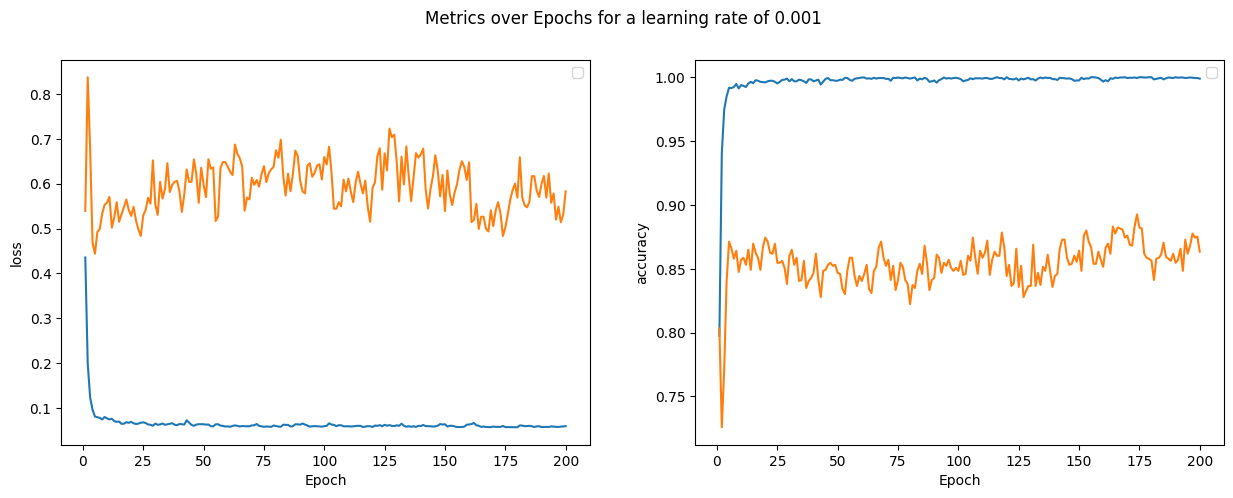

In [ ]:
# Plot results

def plot_results(result, lr=0.001):
    fig, axes = plt.subplots(1,2, figsize=(15, 5))
    axes = axes.flatten()
    history = result.history

    metrics = [
        ["loss", "val_loss"],
#         ["auc", "val_auc"],
        ["accuracy", "val_accuracy"],
#         ["recall", "val_recall"],
#         ["precision", "val_precision"],
#         ["loss", "val_loss"]
    ]


    for i, ax in enumerate(axes):
        metric = metrics[i]

        epochs = range(1, len(history["loss"]) + 1)

        ax.plot(epochs, history[metric[0]])
        ax.plot(epochs, history[metric[1]])
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric[0])

        ax.legend()



    fig.suptitle(f'Metrics over Epochs for a learning rate of {lr}')
#     plt.xlabel('Epoch')
#     plt.ylabel('Metrics')
    plt.legend()
#     plt.grid(True)
    plt.show()


plot_results(results[0])

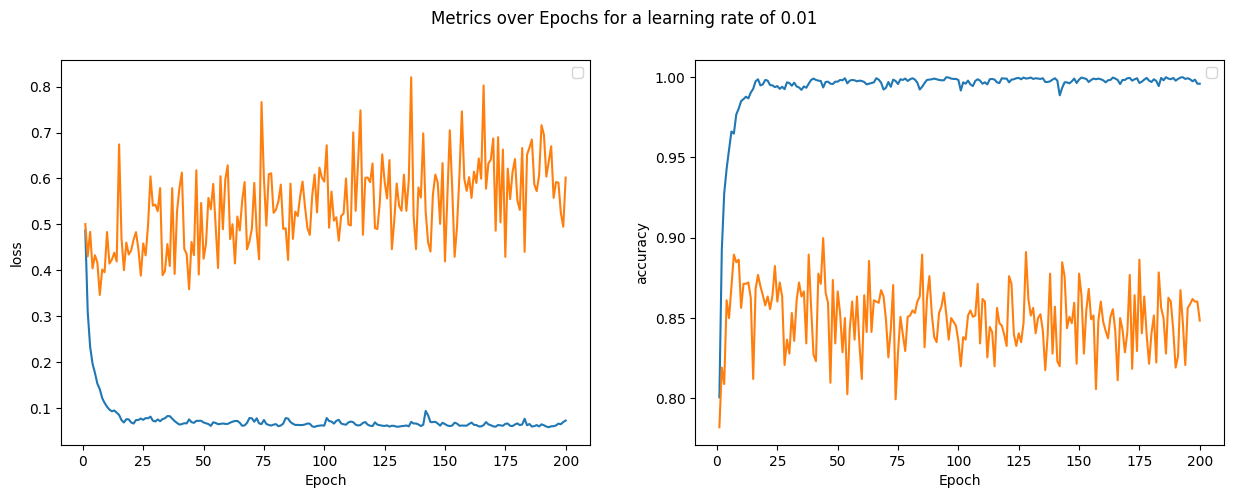

In [ ]:
plot_results(results[1], lr=0.01)

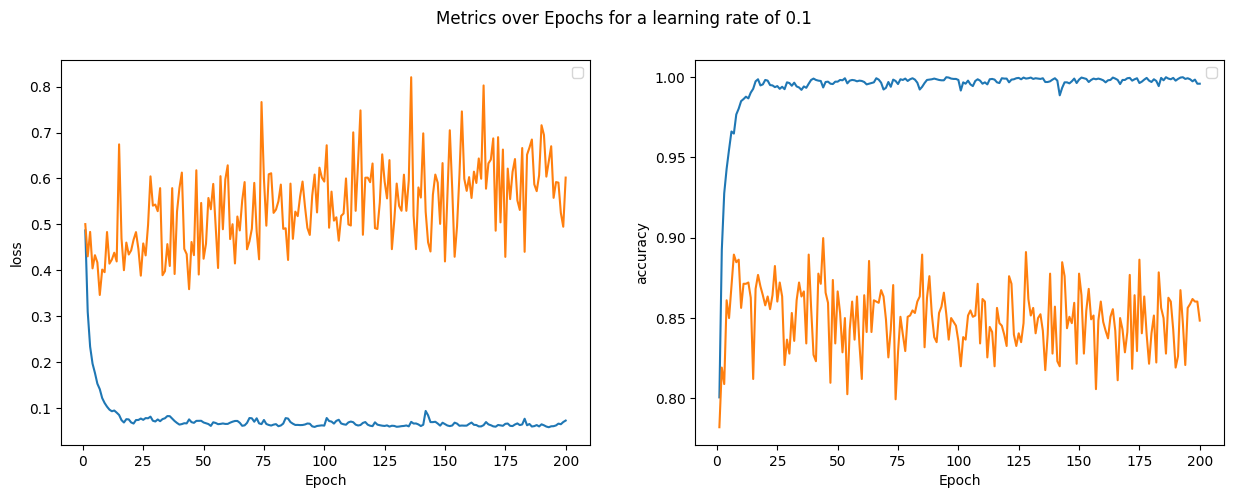

In [ ]:
plot_results(results[1], lr=0.1)

In [ ]:
print(history.history.keys())


NameError: name 'history' is not defined

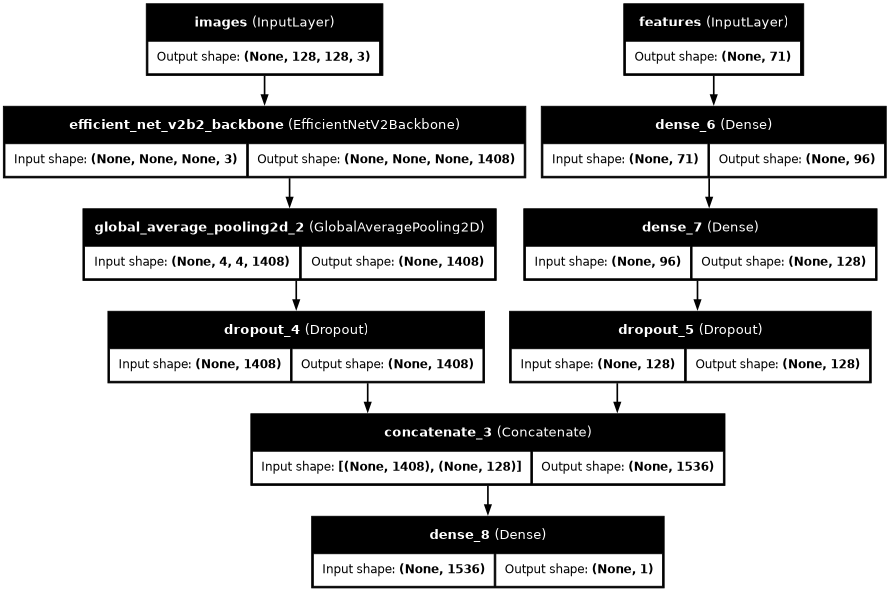

In [ ]:
keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, dpi=60)


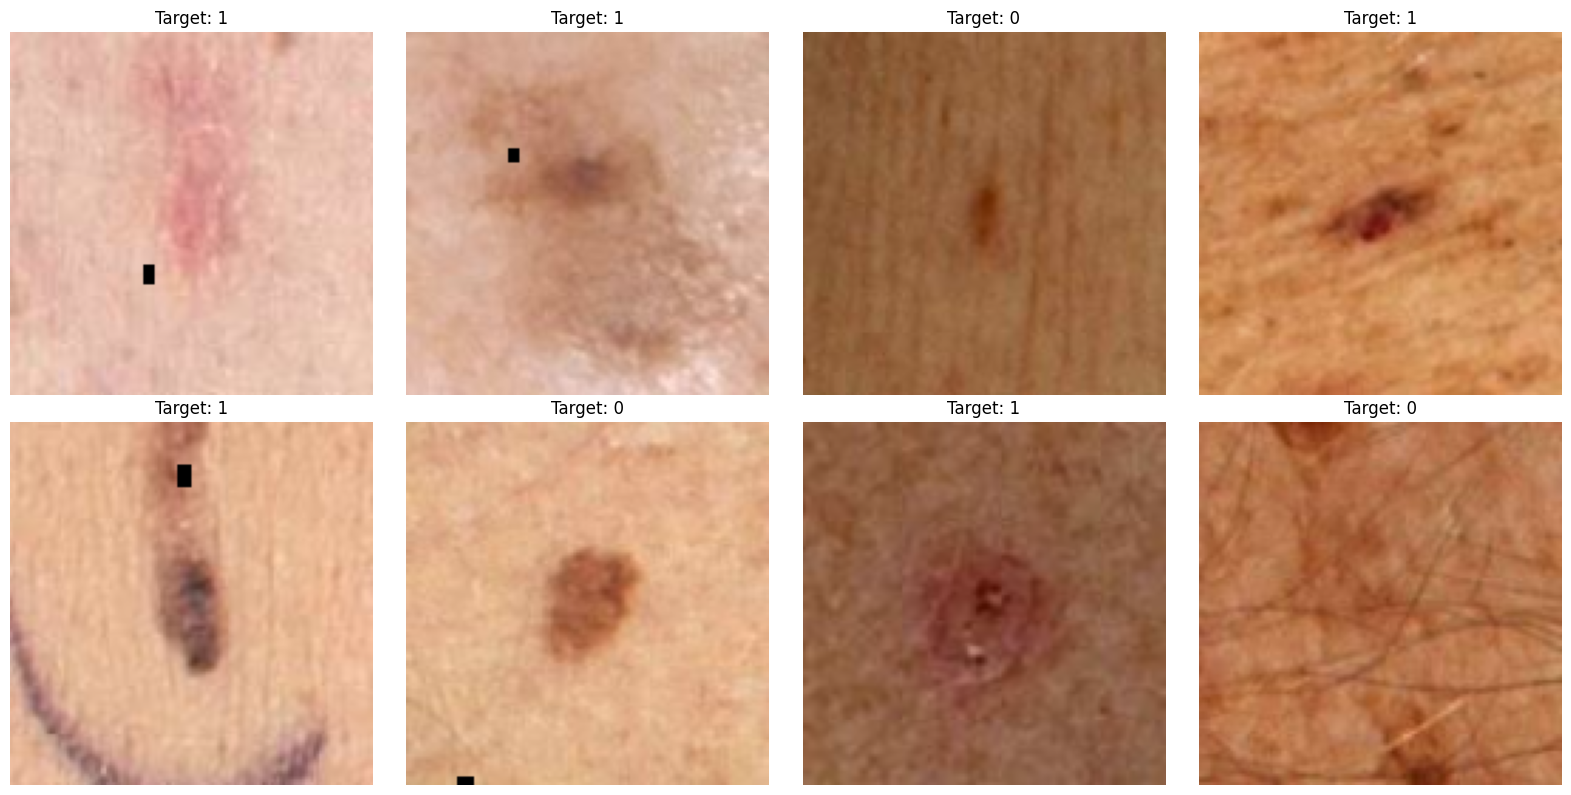

In [ ]:
inputs, targets = next(iter(training_ds))
images = inputs["images"]
num_images, NUMERIC_COLUMNS = 8, 4

plt.figure(figsize=(4 * NUMERIC_COLUMNS, num_images // NUMERIC_COLUMNS * 4))
for i, (image, target) in enumerate(zip(images[:num_images], targets[:num_images])):
    plt.subplot(num_images // NUMERIC_COLUMNS, NUMERIC_COLUMNS, i + 1)
    image = image.numpy().astype("float32")
    target= target.numpy().astype("int32")[0]

    image = (image - image.min()) / (image.max() + 1e-4)

    plt.imshow(image)
    plt.title(f"Target: {target}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# Testing
print("# Testing:")
testing_features = dict(testing_df[FEAT_COLS])
testing_ids = testing_df.isic_id.values
testing_ds = build_dataset(testing_ids, testing_hdf5,
                        testing_features, batch_size=CFG.batch_size,
                         shuffle=False, augment=False, cache=False)
# Apply feature space processing
testing_ds = testing_ds.map(
    lambda x: {"images": x["images"],
               "features": feature_space(x["features"])}, num_parallel_calls=tf.data.AUTOTUNE)

# Testing:


Loading Images :   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
preds = model.predict(testing_ds).squeeze()

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


In [ ]:
preds

array([0.01410884, 0.01173068, 0.0037969 ], dtype=float32)

In [ ]:
from tensorflow.keras.models import load_model

# List to store predictions
predictions = {}

# Load each model and make predictions
for lr in learning_rates:
    # Load the model for this learning rate
    model = load_model(f'best_model_V2-{lr}.keras')

    # Use the model to predict on test data
    pred = model.predict(testing_ds).squeeze()

    # Store the predictions
    predictions[lr] = pred


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


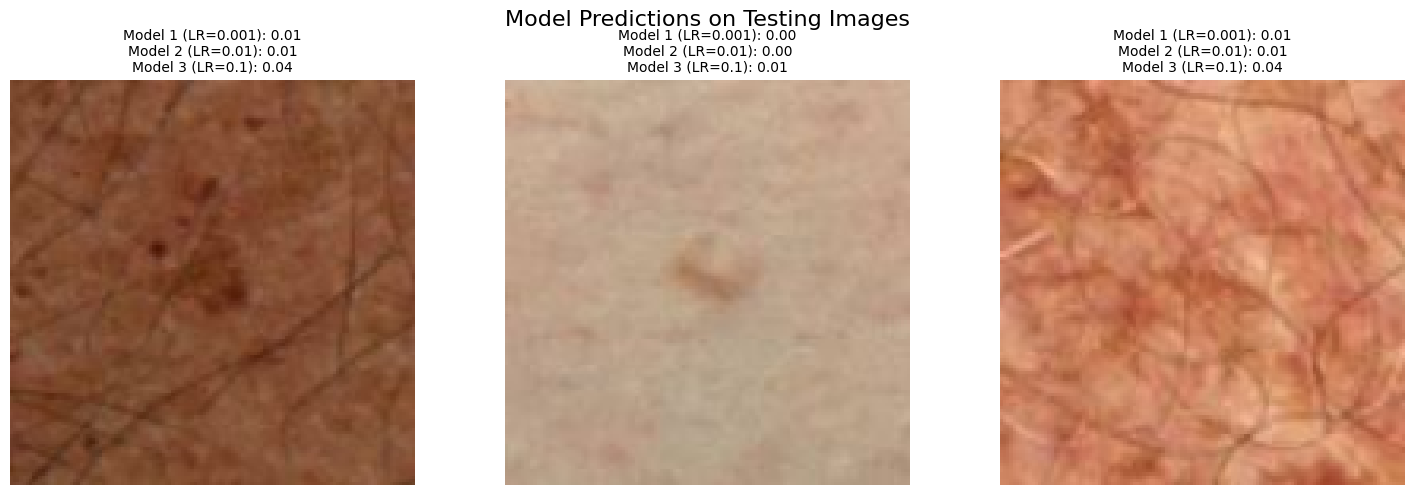

In [ ]:
# Now, let's plot the images and their predictions from each model
plt.figure(figsize=(15, 5))

# Loop through the first 3 images and plot them
for i in range(3):
    plt.subplot(1, 3, i+1)  # 1 row, 3 columns, i+1th subplot
    plt.imshow(images[i])  # Show image

    # Display predictions from the models with different learning rates
    title = (f'Model 1 (LR={learning_rates[0]}): {predictions[learning_rates[0]][i]:.2f}\n'
             f'Model 2 (LR={learning_rates[1]}): {predictions[learning_rates[1]][i]:.2f}\n'
             f'Model 3 (LR={learning_rates[2]}): {predictions[learning_rates[2]][i]:.2f}')

    plt.title(title, fontsize=10)
    plt.axis('off')  # Hide axis

# Add a super title for the entire plot
plt.suptitle('Model Predictions on Testing Images', fontsize=16)
plt.tight_layout()
plt.show()

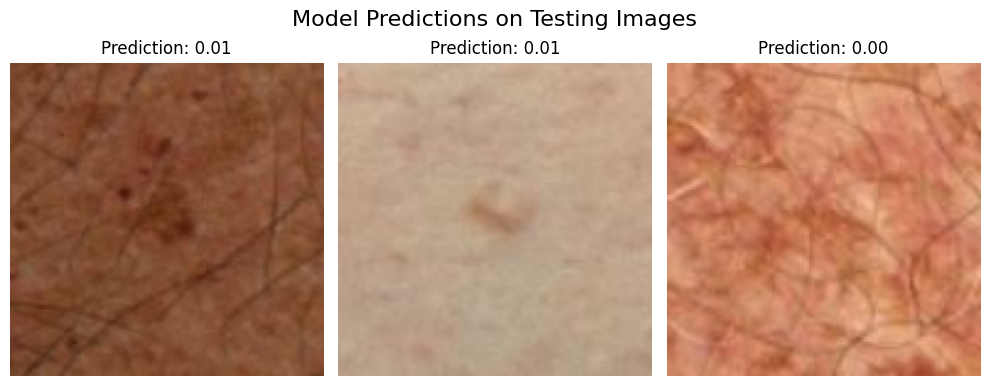

In [ ]:
inputs = next(iter(testing_ds))
images = inputs["images"]

# Plotting
plt.figure(figsize=(10, 4))

for i in range(3):
    plt.subplot(1, 3, i+1)  # 1 row, 3 columns, i+1th subplot
    plt.imshow(images[i])  # Show image
    plt.title(f'Prediction: {preds[i]:.2f}')  # Set title with prediction
    plt.axis('off')  # Hide axis

plt.suptitle('Model Predictions on Testing Images', fontsize=16)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


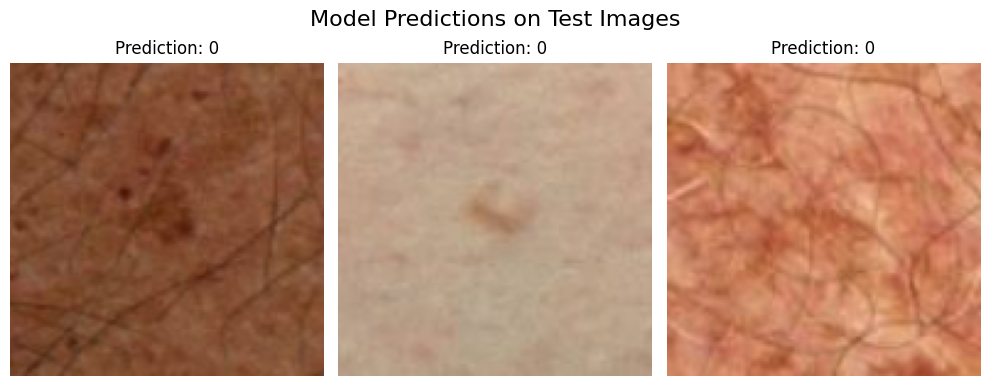

In [ ]:
# Assuming `model` is your trained model and `testing_ds` is your test dataset (without labels)
inputs = next(iter(testing_ds))  # Get one batch of test data
images = inputs["images"]

# Make predictions (assuming model expects 'images' and possibly 'features')
preds = model.predict({"images": images, "features": inputs.get("features")})  # Handle features if present

# Plot the predictions for a few test images
plt.figure(figsize=(10, 4))

for i in range(3):  # Loop to display the first 3 images
    plt.subplot(1, 3, i+1)  # 1 row, 3 columns
    plt.imshow(images[i])  # Show the image
    plt.title(f'Prediction: {np.argmax(preds[i])}')  # Display predicted class
    plt.axis('off')  # Hide axes

plt.suptitle('Model Predictions on Test Images', fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
pred_df = testing_df[["isic_id"]].copy()
pred_df["target"] = preds.tolist()

sub_df = pd.read_csv(f'{BASE_PATH}/sample_submission.csv')
sub_df = sub_df[["isic_id"]].copy()
sub_df = sub_df.merge(pred_df, on="isic_id", how="left")
sub_df.to_csv("submission.csv", index=False)
sub_df.head()

,isic_id,target
0,ISIC_0015657,[0.014108837582170963]
1,ISIC_0015729,[0.0117306774482131]
2,ISIC_0015740,[0.0037969041150063276]




Evaluating model with learning rate: 0.001

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.96      0.91       919
         1.0       0.86      0.58      0.69       347

    accuracy                           0.86      1266
   macro avg       0.86      0.77      0.80      1266
weighted avg       0.86      0.86      0.85      1266



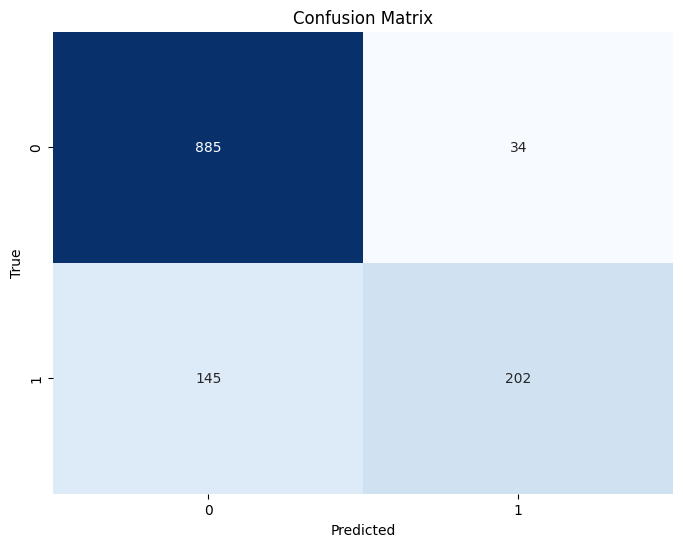

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ images (InputLayer) │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ features            │ (None, 71)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficient_net_v2b2… │ (None, 4, 4,      │  8,769,374 │ images[0][0]      │
│ (EfficientNetV2Bac… │ 1408)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 96)        │      6,912 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1408)      │          0 │ efficient_net_v2… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     12,416 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1408)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 1536)      │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │      1,537 │ concatenate_1[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,206,143 (99.97 MB)

 Trainable params: 8,707,951 (33.22 MB)

 Non-trainable params: 82,288 (321.44 KB)

 Optimizer params: 17,415,904 (66.44 MB)



Evaluating model with learning rate: 0.01

5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step
Classification Report:
               precision    recall  f1-score   support

         0.0       0.90      0.92      0.91       919
         1.0       0.78      0.72      0.75       347

    accuracy                           0.87      1266
   macro avg       0.84      0.82      0.83      1266
weighted avg       0.87      0.87      0.87      1266



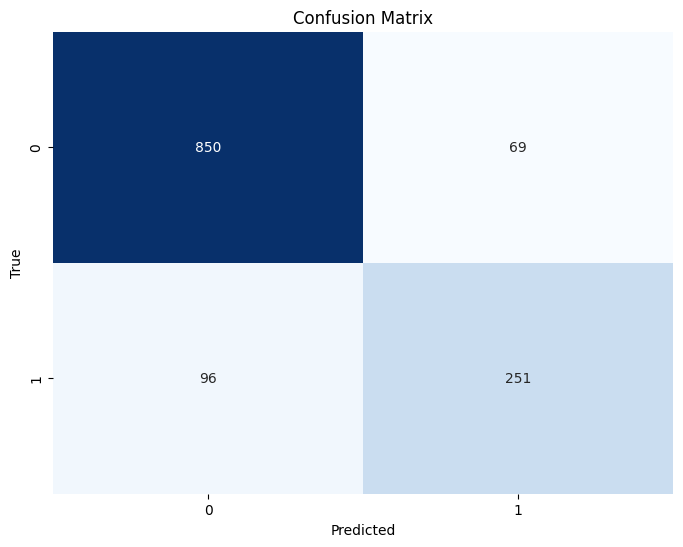

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ images (InputLayer) │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ features            │ (None, 71)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficient_net_v2b2… │ (None, 4, 4,      │  8,769,374 │ images[0][0]      │
│ (EfficientNetV2Bac… │ 1408)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 96)        │      6,912 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1408)      │          0 │ efficient_net_v2… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     12,416 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1408)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 1536)      │          0 │ dropout_2[0][0],  │
│ (Concatenate)       │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │      1,537 │ concatenate_2[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,206,143 (99.97 MB)

 Trainable params: 8,707,951 (33.22 MB)

 Non-trainable params: 82,288 (321.44 KB)

 Optimizer params: 17,415,904 (66.44 MB)



Evaluating model with learning rate: 0.1

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.93      0.90       919
         1.0       0.79      0.65      0.71       347

    accuracy                           0.86      1266
   macro avg       0.83      0.79      0.81      1266
weighted avg       0.85      0.86      0.85      1266



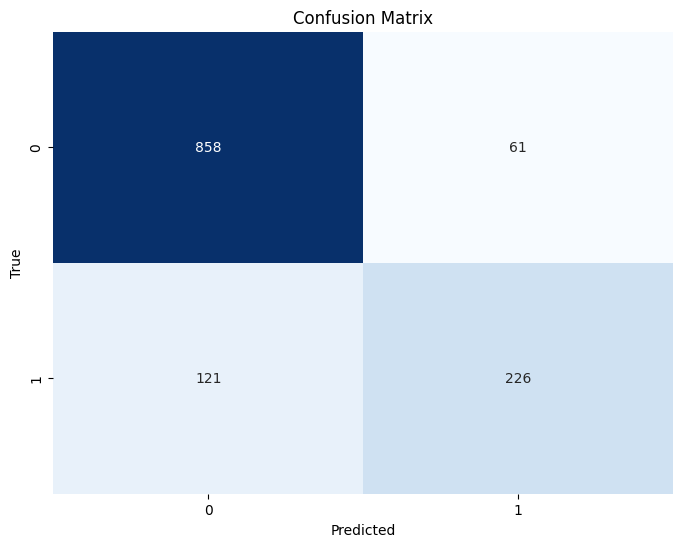

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ images (InputLayer) │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ features            │ (None, 71)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficient_net_v2b2… │ (None, 4, 4,      │  8,769,374 │ images[0][0]      │
│ (EfficientNetV2Bac… │ 1408)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 96)        │      6,912 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1408)      │          0 │ efficient_net_v2… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     12,416 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 1408)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 1536)      │          0 │ dropout_4[0][0],  │
│ (Concatenate)       │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │      1,537 │ concatenate_3[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,206,143 (99.97 MB)

 Trainable params: 8,707,951 (33.22 MB)

 Non-trainable params: 82,288 (321.44 KB)

 Optimizer params: 17,415,904 (66.44 MB)

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Function to generate model report
def generate_model_report(model, testing_ds, threshold=0.5):
    # Predict the probabilities
    y_pred_probs = model.predict(testing_ds)

    # Convert probabilities to binary predictions using the threshold
    y_pred = (y_pred_probs > threshold).astype(int)

    # Get the true labels (assuming testing_ds yields tuples (features, labels))
    y_true = np.concatenate([y for _, y in testing_ds], axis=0)

    # Generate classification report and confusion matrix
    report = classification_report(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print("Classification Report:\n", report)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title("Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()



# Iterate over each model corresponding to a different learning rate
for lr in learning_rates:
    print(f"\n\nEvaluating model with learning rate: {lr}\n")

    # Load the best model for the current learning rate
    model_path = f"/kaggle/working/best_model_V2-{lr}.keras"
    best_model = tf.keras.models.load_model(model_path)

    # Generate the classification report and confusion matrix
    generate_model_report(best_model, validation_ds)

    # Print the model summary (optional, for debugging purposes)
    best_model.summary()
